# **Binary Classification2**

### 1) 실습 개요
이번 실습에서는 이진 교차 엔트로피에 대한 올바른 이해와 함께 직접 이진 분류 모델을 구축하고, 테스트 데이터에 대해 해당 모델을 평가해봅니다.

### 2) 실습 진행 목적 및 배경
이진 분류 모델은 이진 교차 엔트로피와 시그모이드 함수를 바탕으로 특징 변수와 목표 변수 사이의 비선형 관계를 학습합니다. 해당 모델이 구축되는 자세한 이유를 살펴보고 직접 유도해봄으로써 보다 깊은 이해를 도모합니다.

### 3) 실습 수행으로 얻어갈 수 있는 역량
- 이진 교차 엔트로피와 이진 분류 모델을 올바른 이해와 함께 구현할 수 있다.
- 구현한 이진 분류 모델을 학습할 수 있다.
- 구현한 이진 분류 모델을 테스트 데이터에 대해 평가할 수 있다.

### 4) 실습 핵심 내용
&nbsp;&nbsp; 1.3 이진 교차 엔트로피의 유도<br>
&nbsp;&nbsp; 2.1 테스트<br>

### 5) 데이터셋 개요 및 저작권 정보

- 사용 데이터셋: [Iris Dataset](https://www.kaggle.com/datasets/uciml/iris)
  - 붓꽃의 종류(Species), 꽃받침의 길이(SepalLengthCm)와 너비(SepalWidthCm), 꽃잎의 길이(PetalLengthCm)와 너비(PetalWidthCm)이 담긴 데이터셋입니다.
- 저작권 정보: [CC0 1.0 Universal](https://creativecommons.org/publicdomain/zero/1.0/)

### 6) Required Package
```python
torch >= 2.3.0
pandas >= 2.0.3
scikit-learn >= 1.2.2
matplotlib >= 3.7.1
```



In [ ]:
import torch

In [ ]:
# 트레이닝 데이터의 코드 표현 실습

# Kaggle에서 데이터셋 다운로드하는 코드 표현

!kaggle datasets download -d uciml/iris

# 다운로드한 파일의 압축을 해제하는 코드 표현

!unzip iris.zip

Dataset URL: https://www.kaggle.com/datasets/uciml/iris
License(s): CC0-1.0
  0% 0.00/3.60k [00:00<?, ?B/s]
100% 3.60k/3.60k [00:00<00:00, 5.67MB/s]
Archive:  iris.zip
  inflating: Iris.csv                
  inflating: database.sqlite         


In [ ]:
# 트레이닝 데이터의 코드 표현 실습

import pandas as pd
df = pd.read_csv("Iris.csv", sep = ",", header = 0)[["PetalLengthCm", "Species"]] # 데이터 불러오기

filtered_data = df[df['Species'].isin(['Iris-setosa', 'Iris-versicolor'])]

filtered_df = filtered_data

# 목표 변수를 이산형 레이블로 매핑하는 코드 표현 실습

filtered_df.loc[:, 'Species'] = filtered_df['Species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1})

# 특징 변수(features)와 목표 변수(target)을 추출하는 코드 표현 실습

x = filtered_df[['PetalLengthCm']].values
t = filtered_df['Species'].values.astype(int)

# 데이터 분할의 코드 표현 실습

from sklearn.model_selection import train_test_split

x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.2, random_state=42)

# 데이터 표준화의 코드 표현 실습

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# 데이터를 Tensor로 변환하는 코드 표현

x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
t_train = torch.tensor(t_train, dtype=torch.float32).unsqueeze(1)
t_test = torch.tensor(t_test, dtype=torch.float32).unsqueeze(1)

# Dataset 클래스의 코드 표현 실습

from torch.utils.data import Dataset, DataLoader

class IrisDataset(Dataset):   # CustomDataset 클래스
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# DataLoader 생성 코드 표현 실습

train_dataset = IrisDataset(x_train, t_train)
test_dataset = IrisDataset(x_test, t_test)

batch_size = 4  # 배치 크기를 4로 설정
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# 이진 분류 모델 코드 표현 실습

import torch.nn as nn

class BinaryClassificationModel(nn.Module):
    def __init__(self):
        super(BinaryClassificationModel, self).__init__()
        self.layer_1 = nn.Linear(1, 1)  # 입력 차원과 출력 차원을 1로 설정
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        z = self.layer_1(x)
        y = self.sigmoid(z)
        return y

In [ ]:
# 모델 초기화

model = BinaryClassificationModel()

# **1. 이진 교차 엔트로피**

**1.3 이진 교차 엔트로피의 유도**

In [ ]:
# 이진 교차 엔트로피 코드 표현 실습

import torch.optim as optim

loss_function = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [ ]:
# 이진 분류 모델 학습 코드 표현 실습

num_epochs = 500
loss_list = []
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for batch_features, batch_labels in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_features)
        loss = loss_function(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    loss_list.append(epoch_loss / len(train_loader))

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}')

Epoch [100/500], Loss: 0.04523298144340515
Epoch [200/500], Loss: 0.07048282772302628
Epoch [300/500], Loss: 0.01684996485710144
Epoch [400/500], Loss: 0.04065924510359764
Epoch [500/500], Loss: 0.022492501884698868


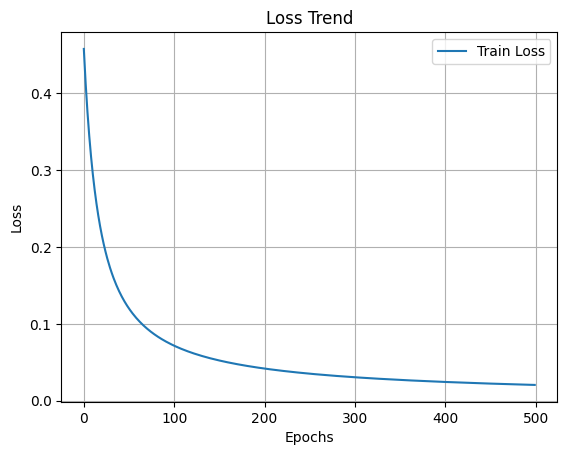

In [ ]:
import matplotlib.pyplot as plt

# 손실 값 변화 시각화
plt.figure()
plt.plot(loss_list, label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Loss Trend')
plt.show()

# **2. 이진 분류 모델의 테스트**

**2.1 테스트**

In [ ]:
# 테스트 데이터의 코드 표현 실습
# 모델을 사용하여 예측

model.eval()
with torch.no_grad():
    predictions = model(x_test)
    predicted_labels = (predictions > 0.5).float()

# 예측 결과와 실제 라벨을 출력하는 코드 표현 실습

actual_labels = t_test.numpy()
predicted_labels = predicted_labels.numpy()

print("Predictions:", predicted_labels.flatten())
print("Actual Labels:", actual_labels.flatten())


Predictions: [1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0.]
Actual Labels: [1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0.]


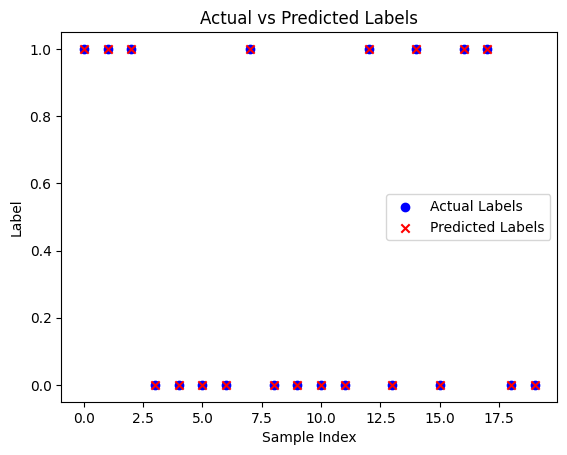

In [ ]:
# 예측 결과를 시각화하는 코드 표현 실습

plt.figure()
plt.scatter(range(len(actual_labels)), actual_labels, color='blue', label='Actual Labels')
plt.scatter(range(len(predicted_labels)), predicted_labels, color='red', marker='x', label='Predicted Labels')
plt.xlabel('Sample Index')
plt.ylabel('Label')
plt.legend()
plt.title('Actual vs Predicted Labels')
plt.show()